# 📊 Análisis operativo en manufactura — OEE, scrap y desempeño

Este notebook analiza rendimiento, scrap, disponibilidad y OEE
para entender cómo los factores operativos afectan la rentabilidad del negocio.


In [ ]:
import pandas as pd
from sqlalchemy import create_engine
import pydoc

In [2]:
import sys, os

# Añadir la carpeta raíz del proyecto al path
project_root = os.path.dirname(os.getcwd())  # sube un nivel: de /notebook a /
sys.path.append(project_root)

print(project_root)  # opcional, para ver que apunta a EMPRESA_MANUFACTURA


c:\Users\ernes\OneDrive\Documentos\progra\Documents\bloque_5_pandas\Empresa_manufactura


##  Carga de datos desde SQL Server


In [3]:

server = "ERNESTO_RIVERA"
database = "Manufactura"

connection_string = (
    "mssql+pyodbc://@{server}/{database}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
).format(server=server, database=database)

engine = create_engine(connection_string)

df = pd.read_sql("SELECT TOP 5 * FROM dim_calendario", engine)
print(df)


        fecha
0  2023-01-01
1  2023-01-02
2  2023-01-03
3  2023-01-04
4  2023-01-05


In [4]:
query_df_master = """
SELECT
    p.fecha,
    p.linea_id,  
    l.nombre_linea,
    pr.nombre_producto,
    p.unidades_producidas,
    p.defectos,
    p.horas_trabajadas,
    v.unidades_vendidas,
    v.precio_unitario,
    v.promo
FROM fact_produccion p
LEFT JOIN dim_linea l
    ON p.linea_id = l.linea_id
LEFT JOIN dim_producto pr
    ON p.producto_id = pr.producto_id
LEFT JOIN fact_ventas v
    ON p.fecha = v.fecha
   AND p.producto_id = v.producto_id
ORDER BY p.fecha;
"""

df_master = pd.read_sql(query_df_master, engine)
df_master.head()


,fecha,linea_id,nombre_linea,nombre_producto,unidades_producidas,defectos,horas_trabajadas,unidades_vendidas,precio_unitario,promo
0,2024-01-01,1,Linea A,Motor AC,120,5,8.0,100,120.0,False
1,2024-01-01,2,Linea B,Cable Industrial,200,10,7.5,180,15.0,False
2,2024-01-02,3,Linea C,Panel Control,90,2,6.0,70,300.0,False
3,2024-01-02,1,Linea A,Motor AC,130,3,8.0,110,120.0,True


## 🎯 Objetivo del análisis

- Evaluar desempeño de líneas de producción
- Medir disponibilidad, rendimiento, calidad y OEE
- Identificar impacto económico del scrap
- Proponer recomendaciones accionables


# Limpieza y preparación de datos


In [5]:
df_master.shape

(4, 10)

# Revisión de nulos

In [6]:
df_master.isna().sum()

fecha                  0
linea_id               0
nombre_linea           0
nombre_producto        0
unidades_producidas    0
defectos               0
horas_trabajadas       0
unidades_vendidas      0
precio_unitario        0
promo                  0
dtype: int64

# Cálculo de métricas operativas (KPIs)


In [7]:
from src.features import cal_yield

df_master["yield_produccion"] = cal_yield(
    df_master,
    "unidades_producidas",
    "defectos"
)

In [8]:
from src.features import cal_scrap

df_master["scrap_rate"] = cal_scrap(
    df_master,
    "defectos",
    "unidades_producidas"
)



In [10]:
df_master["check"] = df_master["yield_produccion"] + df_master["scrap_rate"]
df_master[["yield_produccion", "scrap_rate", "check"]]


,yield_produccion,scrap_rate,check
0,0.958333,0.041667,1.0
1,0.950000,0.050000,1.0
2,0.977778,0.022222,1.0
3,0.976923,0.023077,1.0


# Interpretación del check

* Solo pueden pasar 2 cosas, que haya scrap: materia defectuosa o yield: materia buena, no existe una tercera categoría
* Por eso el resultado tiene que ser siempre 1 porque lo que le falta a uno el otro lo complementa
* En nuestro caso, todo salió a la perfección

In [11]:
from src.features import cal_productividad

df_master["productividad"] = cal_productividad(
    df_master,
    "unidades_producidas",
    "horas_trabajadas"
)

# Creación del dataframe de mantenimiento
* Necesitamos la columna duración horas
* Esto con el fin de realizar el cálculo de la disponibildad

In [12]:
query_mant = """
SELECT
    fecha,
    linea_id,
    duracion_horas
FROM fact_mantenimiento
"""

df_mant = pd.read_sql(query_mant, engine)


# Agrupación de las columnas

* Se realizó la agrupación de las columnas para realizar la respectiva suma de la columna "duracion_horas"
* Renombré la columna "duracion_horas" a "horas_mantenimiento"
* El cúal deja en claro que información tiene la respectiva columna 

In [13]:

mant_agg = (
    df_mant
    .groupby(["fecha", "linea_id"], as_index=False)["duracion_horas"]
    .sum()
    .rename(columns={"duracion_horas": "horas_mantenimiento"})
)


In [ ]:
df_master = df_master.merge(
    mant_agg,
    on=["fecha", "linea_id"],  # misma llave en ambos DF
    how="left"
)



In [18]:
df_master

,fecha,linea_id,nombre_linea,nombre_producto,unidades_producidas,defectos,horas_trabajadas,unidades_vendidas,precio_unitario,promo,yield_produccion,scrap_rate,check,productividad,horas_mantenimiento
0,2024-01-01,1,Linea A,Motor AC,120,5,8.0,100,120.0,False,0.958333,0.041667,1.0,15.000000,0.0
1,2024-01-01,2,Linea B,Cable Industrial,200,10,7.5,180,15.0,False,0.950000,0.050000,1.0,26.666667,0.0
2,2024-01-02,3,Linea C,Panel Control,90,2,6.0,70,300.0,False,0.977778,0.022222,1.0,15.000000,0.0
3,2024-01-02,1,Linea A,Motor AC,130,3,8.0,110,120.0,True,0.976923,0.023077,1.0,16.250000,0.0


In [19]:
from src.features import calc_disponibilidad

df_master["disponibilidad"] = calc_disponibilidad(
    df_master,
    "horas_trabajadas",
    "horas_mantenimiento"
)

# No hubo mantenimiento

* Al no haber mantenimiento en los días de producción, se produjeron valores faltantes, por lo cúal se tomo la decisión de rellenarlos con un 0 mediante la función fillna()

In [15]:
df_master["horas_mantenimiento"] = df_master["horas_mantenimiento"].fillna(0)


In [20]:
df_master[["horas_trabajadas","horas_mantenimiento","disponibilidad"]]

,horas_trabajadas,horas_mantenimiento,disponibilidad
0,8.0,0.0,1.0
1,7.5,0.0,1.0
2,6.0,0.0,1.0
3,8.0,0.0,1.0


# Resultado de la disponibilidad

* Al haber horas de trabajo mayores a mantenimiento, la disponibilidad de las lineas fueron del 100%
* No quiere decir que no hubo mantenimiento, sino que se realizó en los días que no hubo producción

In [ ]:
df_master["calidad"] = df_master["yield_produccion"]
df_master


,fecha,linea_id,nombre_linea,nombre_producto,unidades_producidas,defectos,horas_trabajadas,unidades_vendidas,precio_unitario,promo,yield_produccion,scrap_rate,check,productividad,horas_mantenimiento,disponibilidad,calidad
0,2024-01-01,1,Linea A,Motor AC,120,5,8.0,100,120.0,False,0.958333,0.041667,1.0,15.000000,0.0,1.0,0.958333
1,2024-01-01,2,Linea B,Cable Industrial,200,10,7.5,180,15.0,False,0.950000,0.050000,1.0,26.666667,0.0,1.0,0.950000
2,2024-01-02,3,Linea C,Panel Control,90,2,6.0,70,300.0,False,0.977778,0.022222,1.0,15.000000,0.0,1.0,0.977778
3,2024-01-02,1,Linea A,Motor AC,130,3,8.0,110,120.0,True,0.976923,0.023077,1.0,16.250000,0.0,1.0,0.976923


In [22]:
from src.features import calc_rendimiento
productividad_objetivo = 20 # 20 unidades por hora

df_master["rendimiento"] = calc_rendimiento(
    df_master,
    "productividad",
    productividad_objetivo
)

In [23]:
df_master["OEE"] = (
    df_master["disponibilidad"]
    * df_master["rendimiento"]
    * df_master["calidad"]
)


In [24]:
df_master[["disponibilidad", "rendimiento", "calidad"]]

,disponibilidad,rendimiento,calidad
0,1.0,0.750000,0.958333
1,1.0,1.333333,0.950000
2,1.0,0.750000,0.977778
3,1.0,0.812500,0.976923


In [26]:
df_master[[
    "fecha",
    "nombre_linea",
    "calidad",
    "rendimiento",
    "disponibilidad",
    "OEE"
]]


,fecha,nombre_linea,calidad,rendimiento,disponibilidad,OEE
0,2024-01-01,Linea A,0.958333,0.750000,1.0,0.718750
1,2024-01-01,Linea B,0.950000,1.333333,1.0,1.266667
2,2024-01-02,Linea C,0.977778,0.750000,1.0,0.733333
3,2024-01-02,Linea A,0.976923,0.812500,1.0,0.793750


# Linea B
* La producción fue mayor a la producción objetivo
* En el cúal vamos a limitar el resultado a 100%

In [30]:
df_master["rendimiento"] = df_master["rendimiento"].clip(0, 1)
df_master["OEE"] = df_master["OEE"].clip(0, 1)


In [29]:
df_master[[
    "fecha",
    "nombre_linea",
    "calidad",
    "rendimiento",
    "disponibilidad",
    "OEE"
]]


,fecha,nombre_linea,calidad,rendimiento,disponibilidad,OEE
0,2024-01-01,Linea A,0.958333,0.7500,1.0,0.718750
1,2024-01-01,Linea B,0.950000,1.0000,1.0,1.000000
2,2024-01-02,Linea C,0.977778,0.7500,1.0,0.733333
3,2024-01-02,Linea A,0.976923,0.8125,1.0,0.793750


# La disponibilidad no es el principal problema operativo
* Los datos reflejan que la disponibilidad en los días de producción fueron del 100%
* No se requiere un aumento de disponibilidad ya que este no está afectando los ingresos directamente
* Por lo cúal, la disponibilidad no está afectando las diferencias de desempeño entre las lineas y la variabilidad de ingresos

# Principal diferenciador entre las lineas es el rendimiento
* Los datos reflejan que existen lineas que operan por debajo del rendimiento esperado
* Por lo cúal presentan menor OEE
* Por lo cúal es un dato importante de aclarar porque tanto la disponibilidad como la calidad son relativamente altas

# La calidad es buena pero aún refleja un pequeño impacto económico
* Los indices de calidad reflejan entre 95% y 98%, lo cúal reflejan estabilidad en ese aspecto
* Sin embargo, pequeñas variaciones en el scrap reducen el OEE
* Lo cúal disminuye la cantidad de unidades vendidas, lo cúal genera un impacto económico significativo

# Una linea supera la meta
* Existe al menos una linea que supera el 100% de rendimiento
* Por lo cúal se debería estudiar el funcionamiento de esa linea y tomar en práctica su funcionamiento

# El OEE se concentra entre 70% y 80%
* Este es un rango aceptable pero está por debajo de estándar de clase mundial(85%)
* Por lo cúal refleja una potencial mejora en calidad y rendimiento

# El foco del negocio está en eficiencia operativa
* Dado que los volumenes producidos son relativamente estables y la disponibilidad es alta, los ingresos no dependen de producir más sino de:
* Producir más rápido
* Menos scrap
* Manteniendo la calidad actual
En otras palabras, no se requiere "trabajar más", sino "trabajar mejor"

In [31]:
import matplotlib.pyplot as plt

In [33]:
oee_por_linea =df_master.groupby("nombre_linea")["OEE"].mean()
oee_por_linea

nombre_linea
Linea A    0.756250
Linea B    1.000000
Linea C    0.733333
Name: OEE, dtype: float64

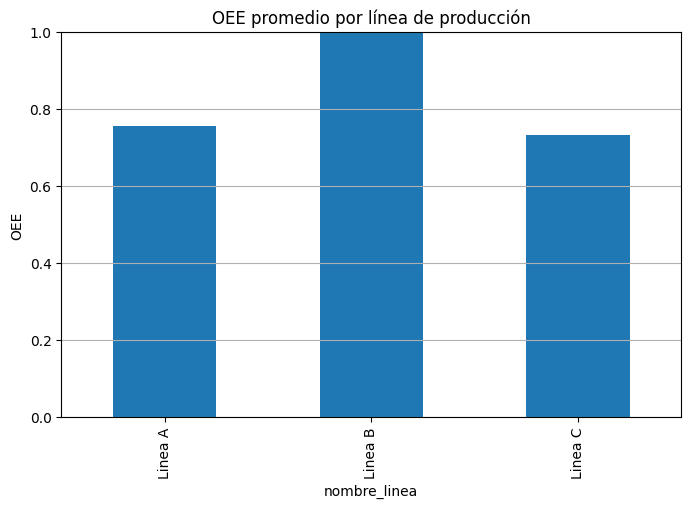

In [36]:
plt.figure(figsize=(8,5))
oee_por_linea.plot(kind="bar")

plt.title("OEE promedio por línea de producción")
plt.ylabel("OEE")
plt.ylim(0,1)
plt.grid(axis="y")
plt.show()


# Linea B con mejor rendimiento de producción
* Como fue descrito antes, la linea B contiene una excelentes prácticas de producción capaz de alcanzar el objetivo esperado
* Por lo cúal, debe ser objeto de estudio para las lineas restantes

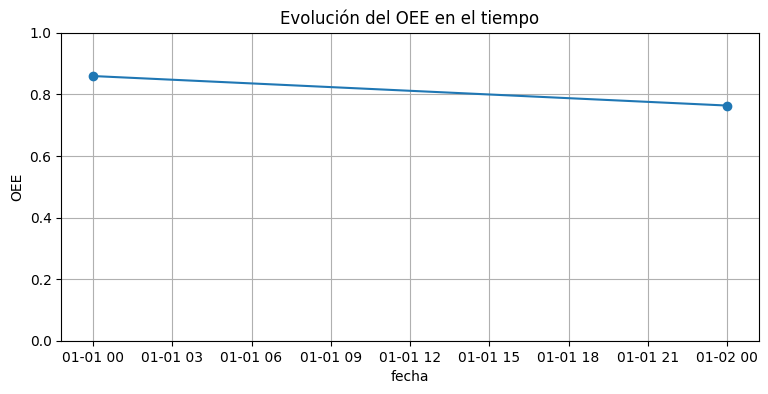

In [37]:
oee_por_fecha = df_master.groupby("fecha")["OEE"].mean()

plt.figure(figsize=(9,4))
oee_por_fecha.plot(marker="o")

plt.title("Evolución del OEE en el tiempo")
plt.ylabel("OEE")
plt.ylim(0,1)
plt.grid()
plt.show()


# Bajo rendimiento global
* Entre los días 01-01 y el día 01-02 hay una reducción de rendimiento, como se describió anteriormente
* Lo cúal está asociado a rendimiento y calidad porque existe una disponibilidad del 100%

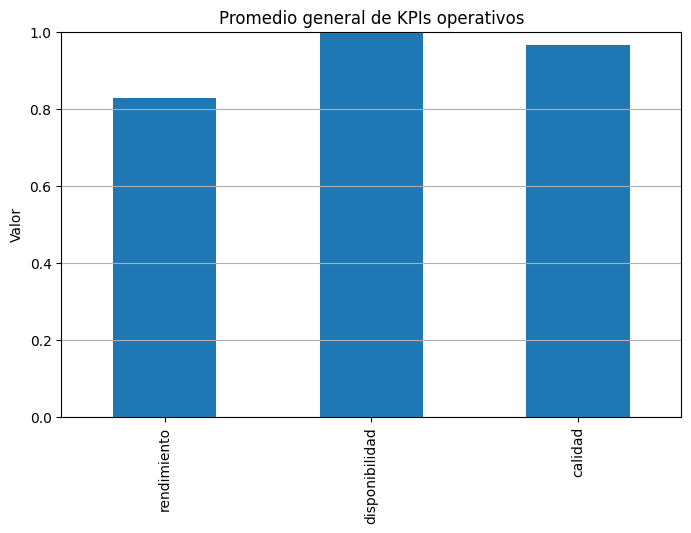

In [38]:
kpis = df_master[["rendimiento","disponibilidad","calidad"]].mean()

plt.figure(figsize=(8,5))
kpis.plot(kind="bar")

plt.title("Promedio general de KPIs operativos")
plt.ylabel("Valor")
plt.ylim(0,1)
plt.grid(axis="y")
plt.show()


# Rendimiento es el problema
* Como se ha descrito antes, el bajo rendimiento tiene impacto en los ingresos economicos
* Calidad es otro factor importante a tomar en cuenta
* Por lo cúal no es "trabajar más" sino "trabajar mejor"

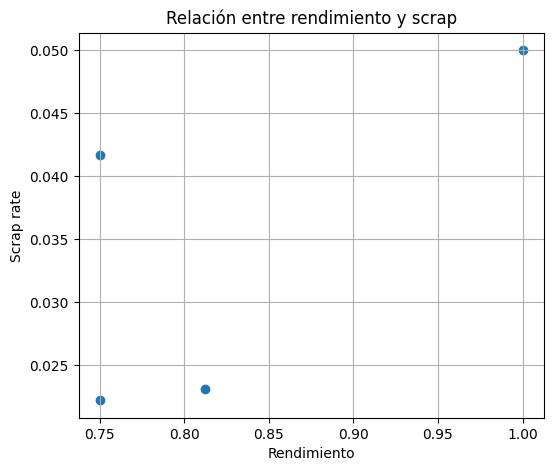

In [39]:
# Descubrir problemas

plt.figure(figsize=(6,5))

plt.scatter(df_master["rendimiento"], df_master["scrap_rate"])

plt.title("Relación entre rendimiento y scrap")
plt.xlabel("Rendimiento")
plt.ylabel("Scrap rate")
plt.grid()
plt.show()


# Mayor rendimiento genera más scrap
* En cuanto aumenta el rendimiento también se sacrifica calidad
* Vemos un aumento de scrap al aumentar rendimiento
* Por lo cúal, no solo es el rendimiento del trabajo sino la eficiencia en la producción de unidades

## 🧭 Recomendación final

Los resultados muestran que el aumento del **rendimiento** también incrementa el **porcentaje de unidades defectuosas (scrap)**.  
Este efecto impacta directamente la **variabilidad económica** y los **ingresos del negocio**.

A continuación se presentan recomendaciones prácticas para enfrentar el problema:

- 🔍 **Identificar la causa raíz del scrap cuando aumenta la producción**
  - posibles causas: errores de operación, fallas de máquina, falta de mantenimiento, falta de entrenamiento
- 🧭 **Priorizar estabilidad del proceso antes de aumentar la velocidad**
  - primero proceso estable → luego incremento de ritmo
- 🎯 **Revisar si el objetivo de rendimiento es realista**
  - metas demasiado altas pueden incentivar defectos
- ⚖️ **Determinar la velocidad óptima de operación**
  - buscar el punto donde el scrap se minimiza y el OEE se maximiza

---

## 🎯 Objetivo principal

- El foco no debe ser operar siempre al **máximo rendimiento**, ya que esto incrementa el scrap.  
- Un rendimiento muy bajo también afecta negativamente los ingresos.  
- La disponibilidad no parece ser el problema principal según los datos analizados.  
- Por lo tanto, se debe **buscar un equilibrio entre rendimiento y calidad**, ya que ambos impactan directamente el desempeño económico de la empresa.

---

## 🧾 Conclusión

> Más que “producir más”, el objetivo debe ser **producir mejor**:  
> estabilidad del proceso, menor scrap y rendimiento en el punto óptimo.
